## Support Vector Machines Project

### For this project we are using "Health Diagnosis" dataset, in which we have 
### Features:
* blood_pressure
* cholesterol
* bmi
* glucose
* diagnosis (Healthy / Risk / Disease)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data = pd.read_csv("health_dataset.csv")

In [3]:
data.head()

,blood_pressure,cholesterol,bmi,glucose,diagnosis
0,120.462439,159.024155,25.284375,82.062184,Healthy
1,101.725855,171.716220,23.016987,98.637839,Healthy
2,105.301443,128.302858,23.489449,106.988587,Healthy
3,103.480613,164.927978,21.419650,84.592168,Healthy
4,105.004778,193.520918,24.138828,80.895173,Healthy


### Create a pairplot of the data set. Which diagnosis sub-catagory seems to be the most separable?

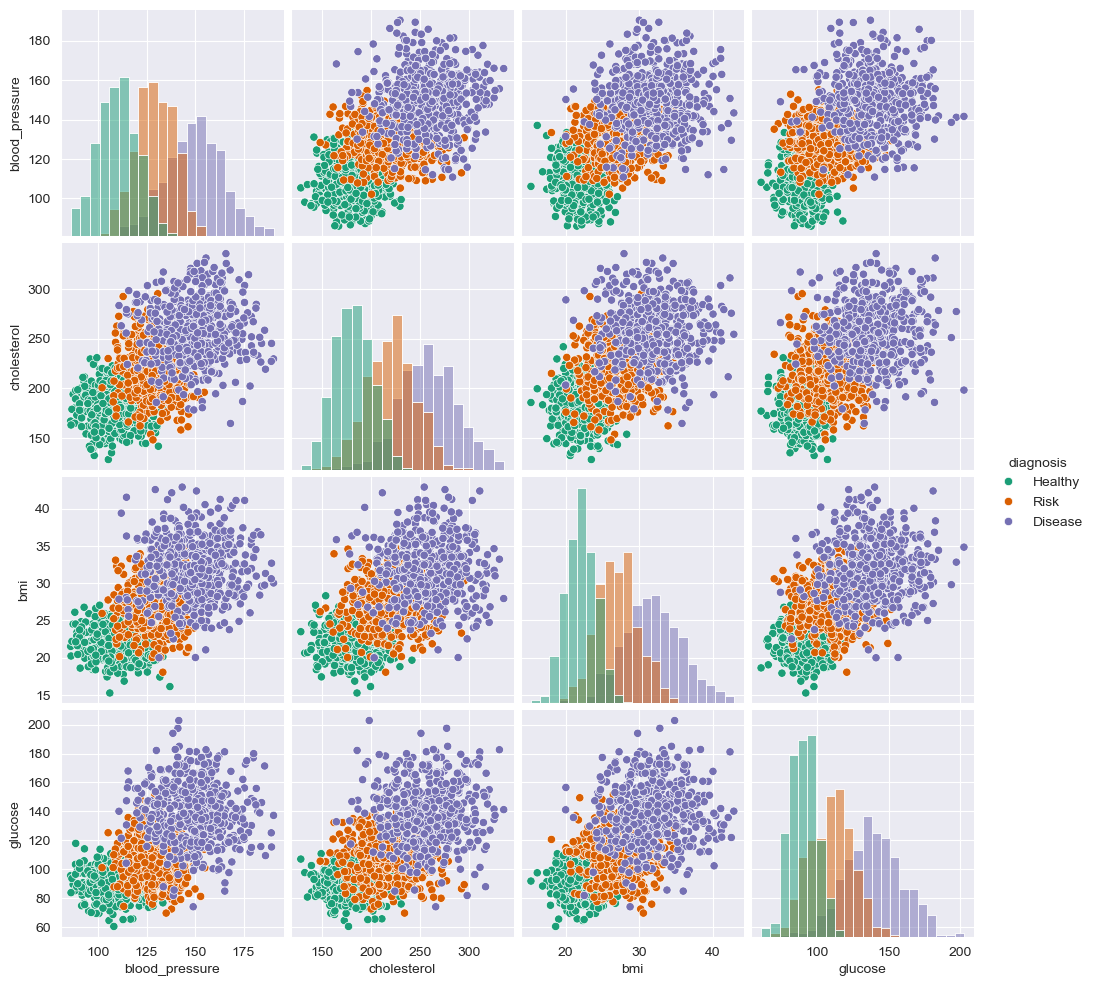

In [4]:
sns.set_style('darkgrid')
sns.pairplot(data,hue='diagnosis',diag_kind='hist',palette='Dark2')

## Train Test Split
### Split your data into a training set and a testing set.

In [5]:
from sklearn.model_selection import train_test_split

In [6]:

X = data.drop('diagnosis',axis=1)
y = data['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33)

## Train a Model
### Now its time to train a Support Vector Machine Classifier.

### Call the SVC() model from sklearn and fit the model to the training data.

In [7]:
from sklearn.svm import SVC

In [8]:
svc_model = SVC()

In [9]:
svc_model.fit(X_train,y_train)

SVC()

## Model Prediction & Evaluation
### Now get predictions from the model and create a confusion matrix and a classification report.

In [10]:
predictions = svc_model.predict(X_test)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
print(confusion_matrix(y_test,predictions))

[[152   0  14]
 [  0 154  12]
 [ 10  11 142]]


In [14]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

     Disease       0.94      0.92      0.93       166
     Healthy       0.93      0.93      0.93       166
        Risk       0.85      0.87      0.86       163

    accuracy                           0.91       495
   macro avg       0.91      0.90      0.91       495
weighted avg       0.91      0.91      0.91       495



## Grid Search Practice

In [15]:
from sklearn.model_selection import GridSearchCV

### Create a dictionary called param_grid and fill out some parameters for C and gamma.

In [16]:
param_grid = {"C":[0.1,1,10,100], "gamma":[1,0.1,0.01,0.001]}

### Create a GridSearchCV object and fit it to the training data.

In [17]:
grid = GridSearchCV(SVC(),param_grid,verbose=2)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.2s
[CV] END .....................................C=0.1, gamma=1; total time=   0.2s
[CV] END .....................................C=0.1, gamma=1; total time=   0.6s
[CV] END .....................................C=0.1, gamma=1; total time=   0.2s
[CV] END .....................................C=0.1, gamma=1; total time=   0.3s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.2s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.2s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.2s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.3s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.2s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.2s
[CV] END ..................................C=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001]},
             verbose=2)

In [18]:
grid_predictions = grid.predict(X_test)

In [19]:
print(confusion_matrix(y_test,grid_predictions))

[[153   0  13]
 [  0 160   6]
 [  8   3 152]]


In [20]:
print(classification_report(y_test,grid_predictions))

              precision    recall  f1-score   support

     Disease       0.95      0.92      0.94       166
     Healthy       0.98      0.96      0.97       166
        Risk       0.89      0.93      0.91       163

    accuracy                           0.94       495
   macro avg       0.94      0.94      0.94       495
weighted avg       0.94      0.94      0.94       495

